In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pymongo import MongoClient
import certifi

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [2]:
USUARIO  = 'joaquinserey_db_user'
PASSWORD = 'joaquin3001'
HOST     = 'datatreaders.xake49k.mongodb.net'
DB       = 'HipotecarioChile'

URI = (f'mongodb+srv://{USUARIO}:{PASSWORD}@{HOST}/{DB}'
       f'?retryWrites=true&w=majority&appName=DataTraders')

client = MongoClient(URI, tlsCAFile=certifi.where())
col    = client[DB]['processed_data']

docs = list(col.find({}, {'_id': 0}))
df   = pd.DataFrame(docs)

print(f'Documentos cargados desde processed_data: {len(df)}')
print(f'Columnas disponibles: {list(df.columns)}')

Documentos cargados desde processed_data: 2469
Columnas disponibles: ['dormitorios', 'tipo_inmueble', 'estacionamiento', 'tipo_interes', 'banco', 'monto', 'cae', 'region', 'pie', 'extractor', 'date', 'url_fuente', 'ubicacion_detalle', 'titulo_proyecto', 'id_registro', 'cae_origen', 'escenario_financiamiento', 'fuente', 'integrante', 'monto_financiado_uf', 'monto_pie_uf', 'plazo_anios', 'tipo_registro', 'url_pagina_scrapeada', 'periodo', 'variacion_mensual', 'tendencia', 'sube_cae', 'cuota_estimada', 'desviacion_vs_banco']


In [3]:
features = ['cae', 'monto', 'pie', 'cuota_estimada', 'desviacion_vs_banco']

df_km = df[features].copy()
for col_name in features:
    df_km[col_name] = pd.to_numeric(df_km[col_name], errors='coerce')

df_km = df_km.dropna()
print(f'Registros válidos para clustering: {len(df_km)}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_km)
print('Datos estandarizados ✓')
print(df_km.describe().round(3))

Registros válidos para clustering: 2469
Datos estandarizados ✓
            cae      monto       pie  cuota_estimada  desviacion_vs_banco
count  2469.000   2469.000  2469.000        2469.000             2469.000
mean      4.563   4724.740    20.352          17.286               -0.000
std       0.596   6124.977     2.259          21.544                0.499
min       3.436   1100.000    10.000           3.740               -1.339
25%       4.143   2000.000    20.000           7.690               -0.185
50%       4.364   2619.000    20.000           9.640                0.029
75%       4.963   3395.000    20.000          13.200                0.246
max       6.268  25791.000    25.000          99.940                1.281


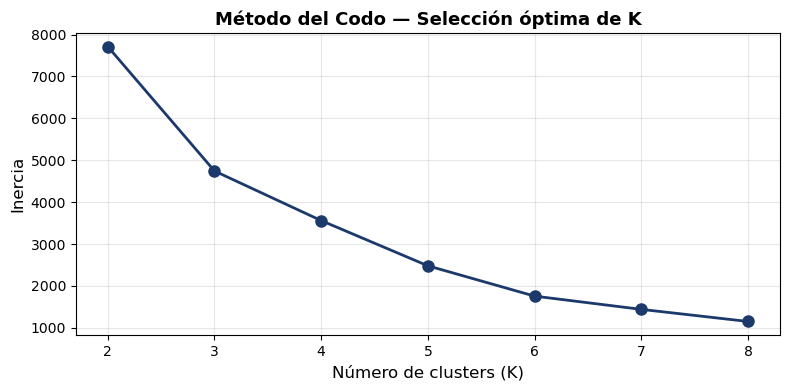

Gráfico guardado: data/kmeans_codo.png ✓


In [4]:
inercias = []
K_range  = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inercias, 'o-', color='#1B3A6B', linewidth=2, markersize=8)
ax.set_xlabel('Número de clusters (K)', fontsize=12)
ax.set_ylabel('Inercia', fontsize=12)
ax.set_title('Método del Codo — Selección óptima de K', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/kmeans_codo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/kmeans_codo.png ✓')

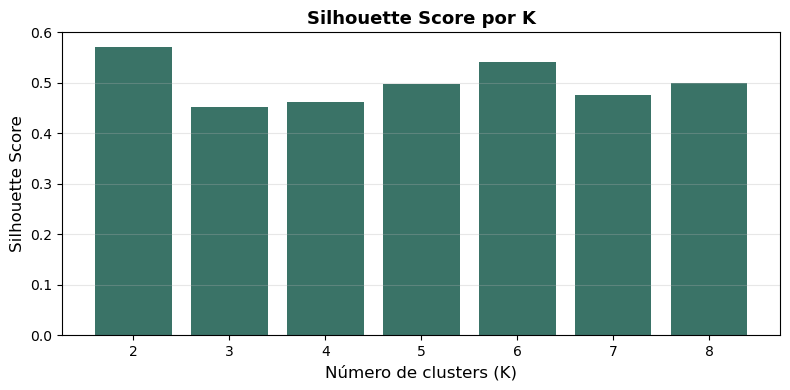

Mejor K según Silhouette: 2 (score=0.5715)


In [5]:
scores = []
for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, lbl))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(list(K_range), scores, color='#085041', alpha=0.8)
ax.set_xlabel('Número de clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score por K', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

mejor_k = list(K_range)[scores.index(max(scores))]
print(f'Mejor K según Silhouette: {mejor_k} (score={max(scores):.4f})')

In [6]:
K_FINAL = 3

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_km['cluster'] = km_final.fit_predict(X_scaled)

df_resultado = df.loc[df_km.index].copy()
df_resultado['cluster'] = df_km['cluster'].values

print(f'Modelo K-Means ajustado con K={K_FINAL} ✓')
print(f'\nDistribución de clusters:')
print(df_km['cluster'].value_counts().sort_index())

Modelo K-Means ajustado con K=3 ✓

Distribución de clusters:
cluster
0     703
1     254
2    1512
Name: count, dtype: int64


In [7]:
perfil = df_km.groupby('cluster')[features].mean().round(4)
print('=== PERFIL PROMEDIO POR CLUSTER ===')
print(perfil.to_string())

orden_cae = perfil['cae'].sort_values()
nombres_cluster = {}
etiquetas = ['Riesgo Bajo', 'Riesgo Medio', 'Riesgo Alto']
for i, idx in enumerate(orden_cae.index):
    nombres_cluster[idx] = etiquetas[i]

df_km['cluster_nombre']      = df_km['cluster'].map(nombres_cluster)
df_resultado['cluster_nombre'] = df_km['cluster_nombre'].values

print('\nEtiquetas asignadas:', nombres_cluster)

=== PERFIL PROMEDIO POR CLUSTER ===
            cae       monto      pie  cuota_estimada  desviacion_vs_banco
cluster                                                                  
0        5.3704   2162.2432  21.4154          9.6739               0.4961
1        4.2520  22091.9764  20.0000         78.2928              -0.0010
2        4.2393   2998.6541  19.9173         10.5774              -0.2306

Etiquetas asignadas: {2: 'Riesgo Bajo', 1: 'Riesgo Medio', 0: 'Riesgo Alto'}


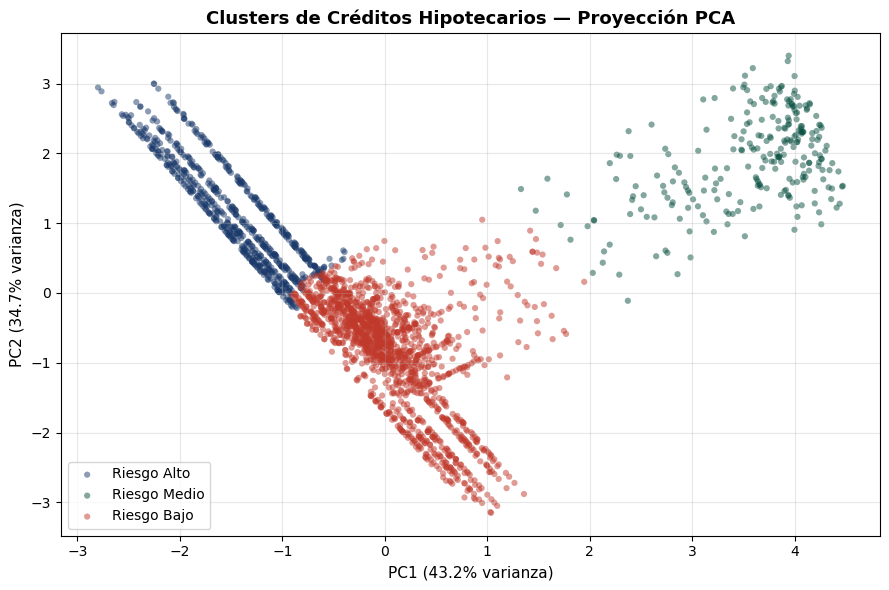

Gráfico guardado: data/kmeans_pca.png ✓


In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

colores = {0:'#1B3A6B', 1:'#085041', 2:'#C0392B'}
fig, ax = plt.subplots(figsize=(9, 6))

for c in sorted(df_km['cluster'].unique()):
    mask = df_km['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colores[c], label=nombres_cluster[c],
               alpha=0.5, s=20, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax.set_title('Clusters de Créditos Hipotecarios — Proyección PCA', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('data/kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/kmeans_pca.png ✓')

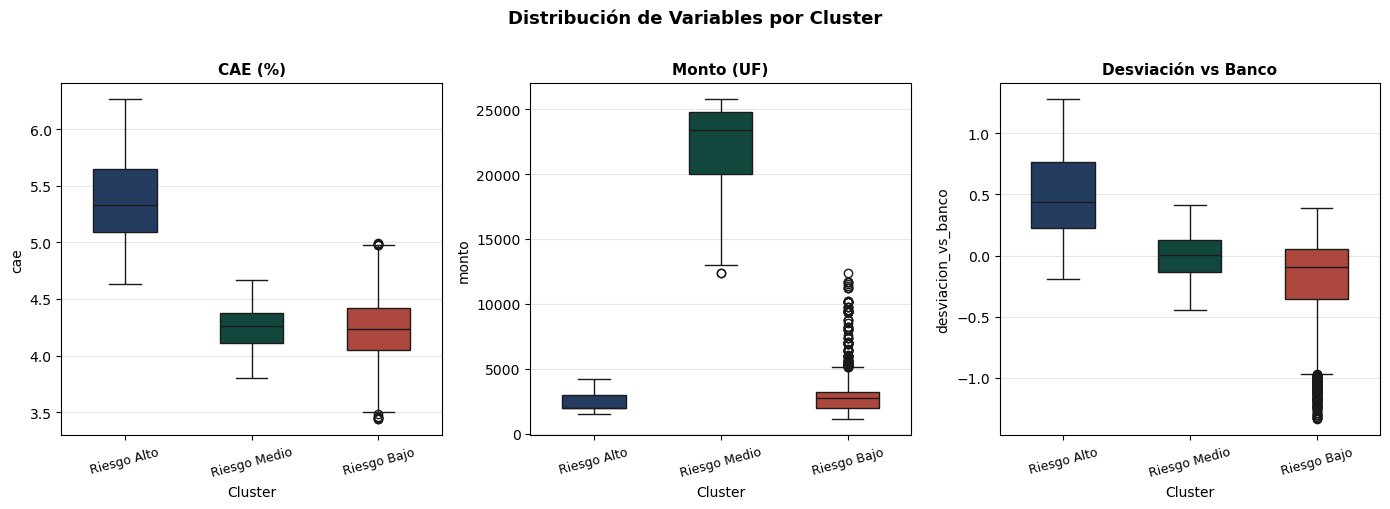

Gráfico guardado: data/kmeans_boxplots.png ✓


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
vars_plot = ['cae', 'monto', 'desviacion_vs_banco']
titulos   = ['CAE (%)', 'Monto (UF)', 'Desviación vs Banco']

df_km['cluster_str'] = df_km['cluster'].astype(str)
palette = {'0':'#1B3A6B', '1':'#085041', '2':'#C0392B'}

for ax, var, tit in zip(axes, vars_plot, titulos):
    sns.boxplot(data=df_km, x='cluster_str', y=var,
                palette=palette, ax=ax, width=0.5,
                order=['0','1','2'])
    ax.set_title(tit, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_xticklabels([nombres_cluster[0], nombres_cluster[1], nombres_cluster[2]], rotation=15, fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de Variables por Cluster', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/kmeans_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: data/kmeans_boxplots.png ✓')

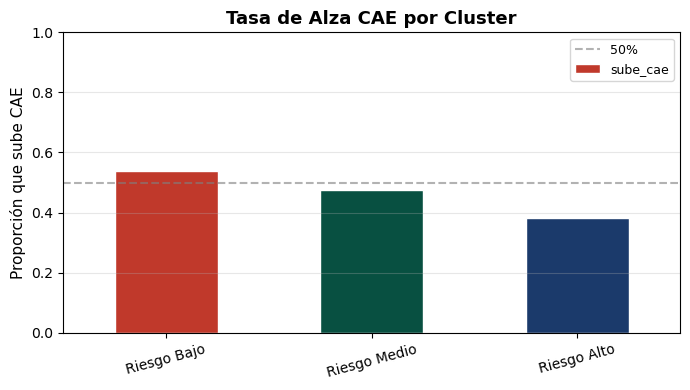


Tasa de alza CAE por cluster:
cluster_nombre
Riesgo Bajo     0.5397
Riesgo Medio    0.4764
Riesgo Alto     0.3812

Gráfico guardado: data/kmeans_vs_variableY.png ✓


In [10]:
if 'sube_cae' in df_resultado.columns:
    df_resultado['sube_cae'] = pd.to_numeric(df_resultado['sube_cae'], errors='coerce')
    tabla = df_resultado.groupby('cluster_nombre')['sube_cae'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4))
    colores_bar = ['#C0392B', '#085041', '#1B3A6B']
    tabla.plot(kind='bar', ax=ax, color=colores_bar[:len(tabla)], edgecolor='white')
    ax.set_ylabel('Proporción que sube CAE', fontsize=11)
    ax.set_xlabel('')
    ax.set_title('Tasa de Alza CAE por Cluster', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50%')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig('data/kmeans_vs_variableY.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nTasa de alza CAE por cluster:')
    print(tabla.round(4).to_string())
    print('\nGráfico guardado: data/kmeans_vs_variableY.png ✓')
else:
    print('Columna sube_cae no encontrada — verifica que estás usando processed_data')

In [11]:
print('=' * 55)
print('   RESUMEN K-MEANS — DataTraders Hito 2')
print('=' * 55)
print(f'Total registros segmentados : {len(df_km)}')
print(f'K óptimo elegido            : {K_FINAL}')
print(f'Variables usadas            : {features}')
print()
print('Distribución final:')
for c, nombre in sorted(nombres_cluster.items()):
    n = (df_km['cluster'] == c).sum()
    pct = n / len(df_km) * 100
    print(f'  Cluster {c} — {nombre}: {n} docs ({pct:.1f}%)')
print()
print('Gráficos generados en scrapers/data/:')
for g in ['kmeans_codo.png','kmeans_silhouette.png','kmeans_pca.png',
          'kmeans_boxplots.png','kmeans_vs_variableY.png']:
    print(f'  ✓ {g}')
print('=' * 55)

   RESUMEN K-MEANS — DataTraders Hito 2
Total registros segmentados : 2469
K óptimo elegido            : 3
Variables usadas            : ['cae', 'monto', 'pie', 'cuota_estimada', 'desviacion_vs_banco']

Distribución final:
  Cluster 0 — Riesgo Alto: 703 docs (28.5%)
  Cluster 1 — Riesgo Medio: 254 docs (10.3%)
  Cluster 2 — Riesgo Bajo: 1512 docs (61.2%)

Gráficos generados en scrapers/data/:
  ✓ kmeans_codo.png
  ✓ kmeans_silhouette.png
  ✓ kmeans_pca.png
  ✓ kmeans_boxplots.png
  ✓ kmeans_vs_variableY.png


In [12]:
from pymongo import UpdateOne

col_out = client[DB]['clustered_data']
ops = []
for _, row in df_resultado.iterrows():
    doc = row.to_dict()
    ops.append(UpdateOne(
        {'cae': doc['cae'], 'banco': doc.get('banco'), 'date': doc.get('date')},
        {'$set': {'cluster': int(doc['cluster']), 'cluster_nombre': doc['cluster_nombre']}},
        upsert=True
    ))

if ops:
    result = col_out.bulk_write(ops)
    print(f'Documentos guardados en clustered_data: {result.upserted_count + result.modified_count}')

Documentos guardados en clustered_data: 42
